## Chapter 9 - Applied

### Question 4

In [403]:
# Book's imports
import numpy as np
from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay

# My immports
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay,
    accuracy_score
)
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, scale
import matplotlib.pyplot as plt

In [404]:
# Set up a random generator
rng = np.random.default_rng(seed=0)

# Generate data
X = rng.standard_normal(size=(100,2))
y = np.array([0]*50 + [1]*50)

# Create a division on the data
X[:25] += 2
X[25:50] -= 2

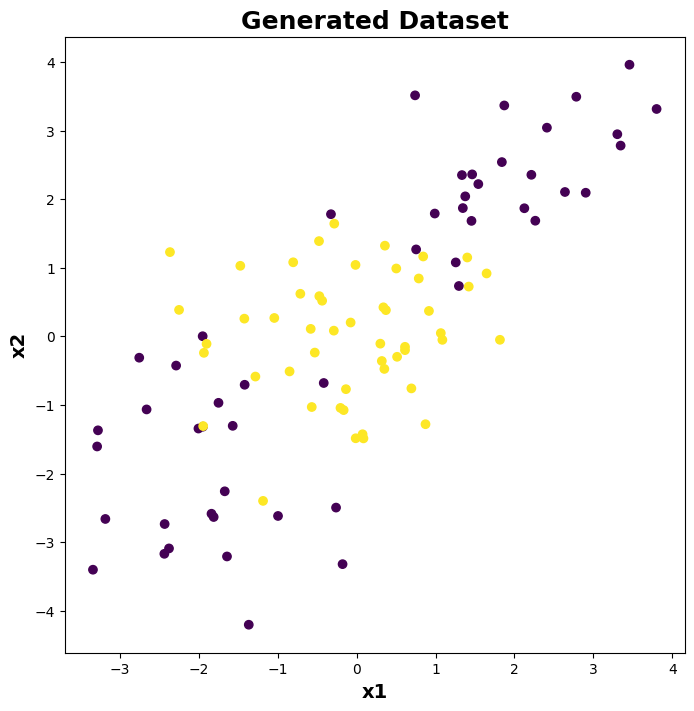

In [405]:
# Plot
ax = subplots(figsize=(8, 8))[1]
ax.scatter(X[:, 0], X[:, 1], c=y)

# Customize
plt.title('Generated Dataset', fontsize=18, fontweight='bold')
plt.xlabel('x1', fontsize=14, fontweight='bold')
plt.ylabel('x2', fontsize=14, fontweight='bold');

In [406]:
# Split data into train/test
X_train, X_test, y_train, y_test = skm.train_test_split(
    X, y, random_state=0, shuffle=True
)

In [407]:
# Set up a Support Vector Classifier
svc = SVC(C=1, kernel='linear', random_state=0).fit(X_train, y_train)

# Predict on train & test datasets
y_hat_train = svc.predict(X_train)
y_hat_test = svc.predict(X_test)

# Accuracy
acc_train = accuracy_score(y_train, y_hat_train)
acc_test = accuracy_score(y_test, y_hat_test)

# Print information
print(f"""
Support Vector Classifier
-------------------------
acc_train: {round(acc_train*100, 2)}
acc_test:  {round(acc_test*100, 2)}
""")


Support Vector Classifier
-------------------------
acc_train: 61.33
acc_test:  44.0



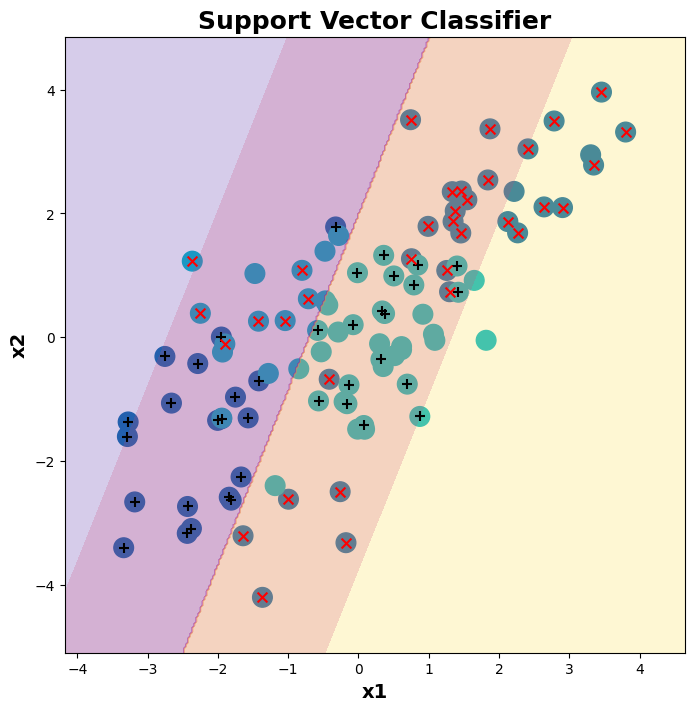

In [411]:
# Plot
ax = subplots(figsize=(8, 8))[1]
plot_svm(X, y, svc, ax=ax)

# Customize
plt.title('Support Vector Classifier', fontsize=18, fontweight='bold')
plt.xlabel('x1', fontsize=14, fontweight='bold')
plt.ylabel('x2', fontsize=14, fontweight='bold');

In [413]:
# Set up a Support Vector Machine ('rbf')
svm = SVC(C=1, kernel='rbf', gamma=1, random_state=0).fit(X_train, y_train)

# Predict on train & test datasets
y_hat_train = svm.predict(X_train)
y_hat_test = svm.predict(X_test)

# Accuracy
acc_train = accuracy_score(y_train, y_hat_train)
acc_test = accuracy_score(y_test, y_hat_test)

# Print informaiton
print(f"""
Support Vector Machine ('rbf')
----------------------
acc_train: {round(acc_train*100, 2)}
acc_test:  {round(acc_test*100, 2)}
""")


Support Vector Machine ('rbf')
----------------------
acc_train: 93.33
acc_test:  80.0



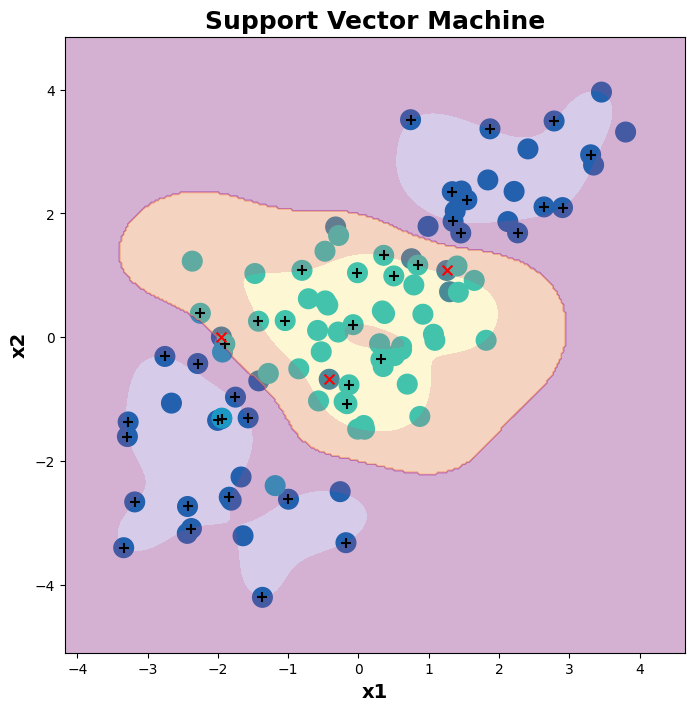

In [414]:
# Plot
ax = subplots(figsize=(8, 8))[1]
plot_svm(X, y, svm, ax=ax)

# Customize
plt.title('Support Vector Machine', fontsize=18, fontweight='bold')
plt.xlabel('x1', fontsize=14, fontweight='bold')
plt.ylabel('x2', fontsize=14, fontweight='bold');

The accuracy metrics and visualizations clearly demonstrate that the Support Vector Classifier (SVC) is outperformed by the Support Vector Machine (SVM) with a radial kernel. The radial kernel SVM achieves significantly higher accuracy on both the training and test datasets. Additionally, the plots highlight how the radial kernel effectively captures the non-linear patterns in the data, making it a far superior choice for this scenario.

---

### Question 5

#### 5a)

In [448]:
# Generate the dataset
rng = np.random.default_rng(5)
x1 = rng.uniform(size=500) - 0.5
x2 = rng.uniform(size=500) - 0.5
y = x1**2 - x2**2 > 0

#### 5b)

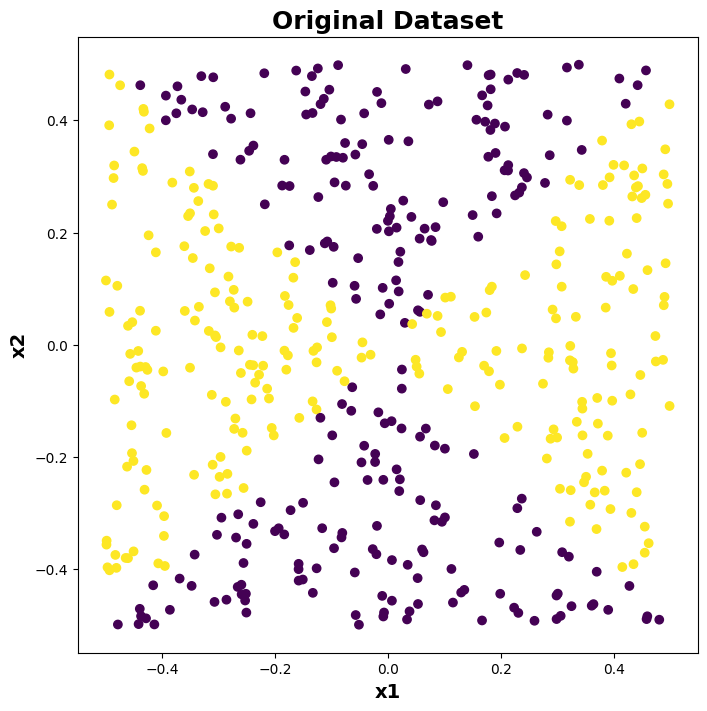

In [449]:
# Plot
ax = subplots(figsize=(8,8))[1]
ax.scatter(x1, x2, c=y)

# Customize
plt.title('Original Dataset', fontsize=18, fontweight='bold')
plt.xlabel('x1', fontsize=14, fontweight='bold')
plt.ylabel('x2', fontsize=14, fontweight='bold');

#### 5c)

In [450]:
# Create the dataset
X = np.hstack((x1.reshape((-1,1)), x2.reshape((-1,1))))

# Set up & fit the Logistic Regression model
lr = LogisticRegression().fit(X, y)

#### 5d)

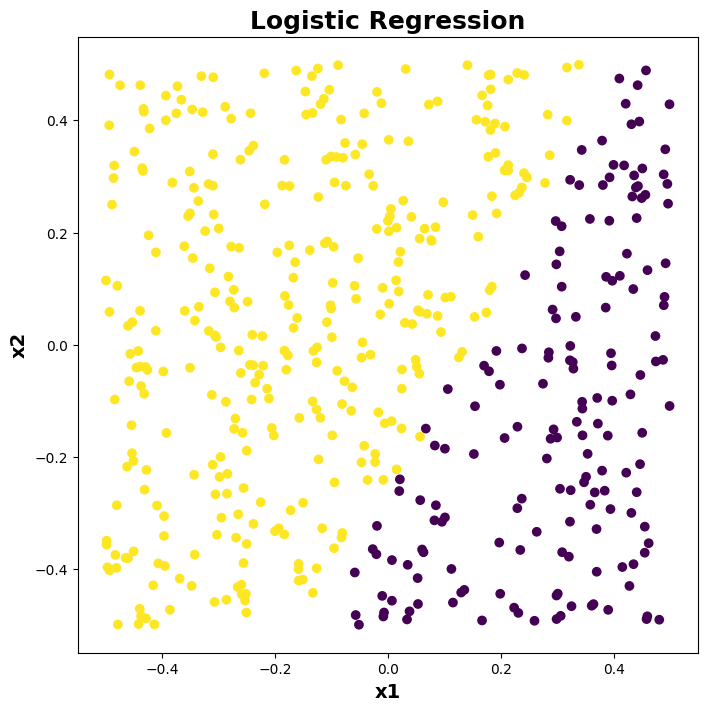

In [451]:
# Predict labels
y_hat = lr.predict(X)

# Plot predictions
ax = subplots(figsize=(8,8))[1]
ax.scatter(X[:, 0], X[:, 1], c=y_hat)

# Customize
plt.title('Logistic Regression', fontsize=18, fontweight='bold')
plt.xlabel('x1', fontsize=14, fontweight='bold')
plt.ylabel('x2', fontsize=14, fontweight='bold');

In [452]:
# Get the accuracy
acc = accuracy_score(y, y_hat)

# Print information
print(f"""
Logistic Regression
-------------------
acc = {round(acc*100, 2)}
""")


Logistic Regression
-------------------
acc = 43.0



As expected, the plot shows a linear decision boundary from the logistic regression, and that leads to a poor accuracy of 43%.

Model performance could improve by setting 'fit_intercept=False', but we know this because we generated the data.

#### 5e)

In [453]:
# Create a simplified polynomial function
def poly_simplified(x, degree):
    # Ensure x is a column vector
    x = np.asarray(x).reshape(-1,1)
    # Create a polynomial matrix
    X = np.hstack([x**i for i in range(degree+1)])
    # Remove intercept
    X = X[:, 1:]
    return X

# Initialize new datasets
dataset = False

# Loop through features
for i in range(X.shape[1]):

    # Get feature
    x = X[:, i]
    
    # Create 2 and 3 degree simplified features
    poly2 = poly_simplified(x, 2)
    poly3 = poly_simplified(x, 3)

    # Check if matrix exists
    if dataset:        
        # Update datasets
        X2_simplified = np.hstack((X2_simplified, poly2))
        X3_simplified = np.hstack((X3_simplified, poly3))

    else:
        X2_simplified = poly2
        X3_simplified = poly3
        # Dataset now exists
        dataset = True

In [454]:
# Set up polynomial methods
poly2 = PolynomialFeatures(2)
poly3 = PolynomialFeatures(3)

# Create regular polynomials
X2 = poly2.fit_transform(X)
X3 = poly3.fit_transform(X)

In [455]:
# Fit logistic regressions to datasets
lr2 = LogisticRegression(fit_intercept=False).fit(X2, y)
lr3 = LogisticRegression(fit_intercept=False).fit(X3, y)
lr2_simplified = LogisticRegression(fit_intercept=False).fit(X2_simplified, y)
lr3_simplified = LogisticRegression(fit_intercept=False).fit(X3_simplified, y)

#### 5f)

In [456]:
# Predict on training dataset
y_hat_lr2 = lr2.predict(X2)
y_hat_lr3 = lr3.predict(X3)
y_hat_lr2_simplified = lr2_simplified.predict(X2_simplified)
y_hat_lr3_simplified = lr3_simplified.predict(X3_simplified)

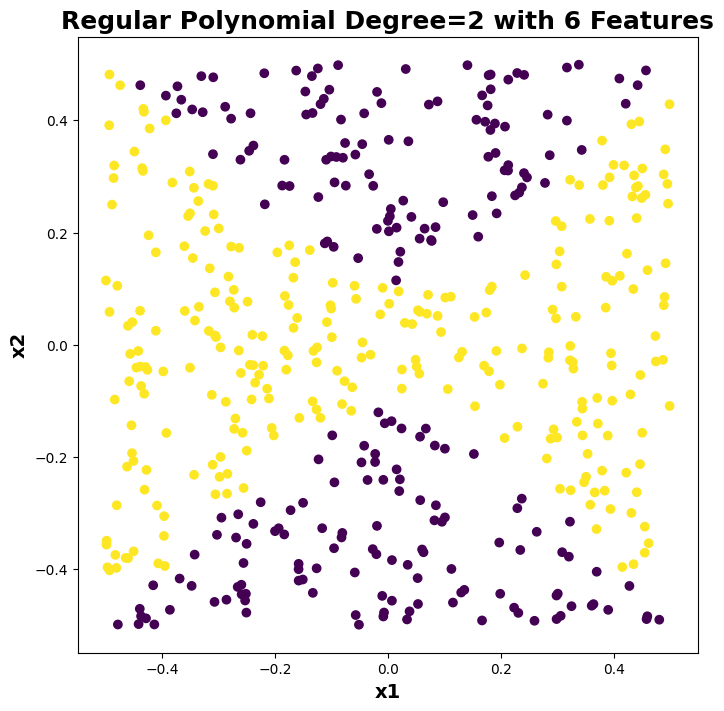

In [459]:
# Plot lr2
ax = subplots(figsize=(8,8))[1]
ax.scatter(X[:, 0], X[:, 1], c=y_hat_lr2)

# Customize
plt.title('Regular Polynomial Degree=2 with 6 Features', fontsize=18, fontweight='bold')
plt.xlabel('x1', fontsize=14, fontweight='bold')
plt.ylabel('x2', fontsize=14, fontweight='bold');

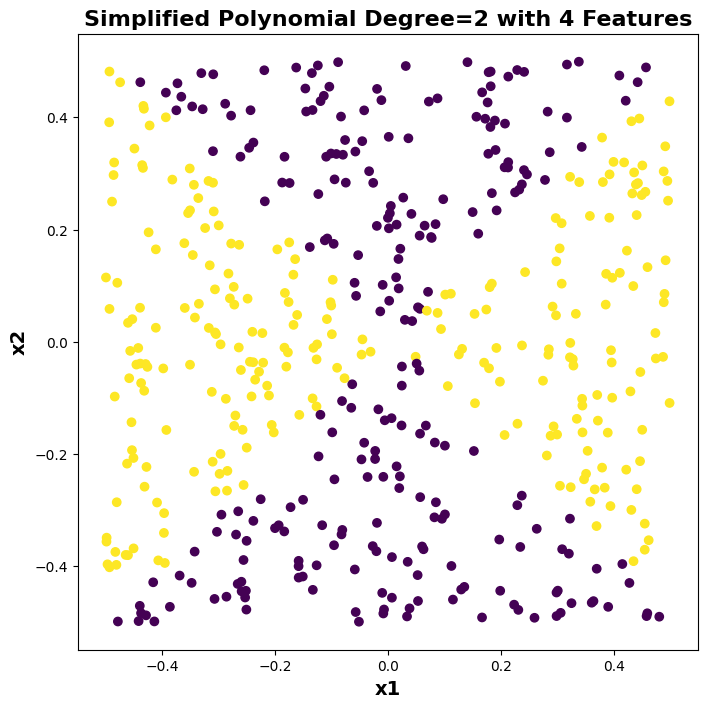

In [460]:
# Plot lr2_simplified
ax = subplots(figsize=(8,8))[1]
ax.scatter(X[:, 0], X[:, 1], c=y_hat_lr2_simplified)

# Customize
plt.xlabel('x1', fontsize=14, fontweight='bold')
plt.ylabel('x2', fontsize=14, fontweight='bold');
plt.title(
    'Simplified Polynomial Degree=2 with 4 Features', 
    fontsize=16,
    fontweight='bold'
);

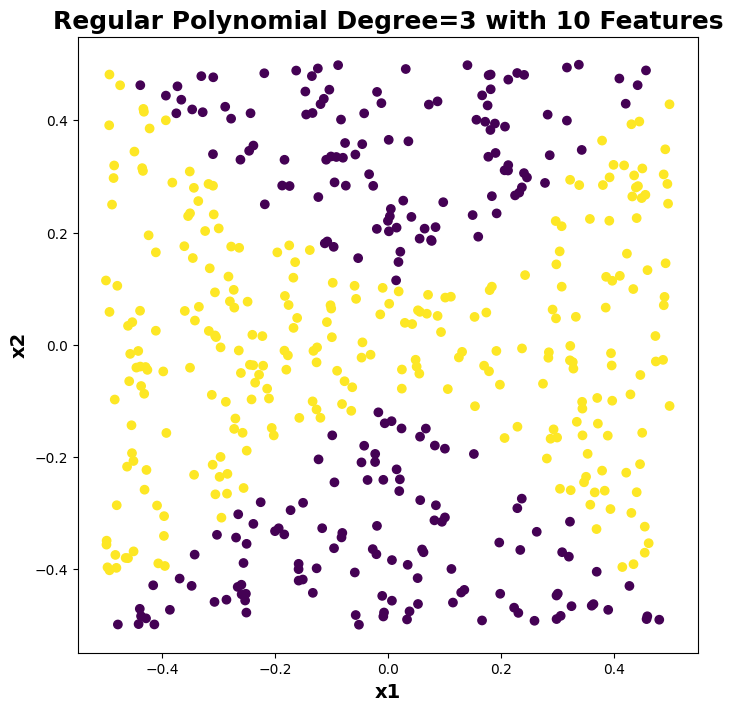

In [461]:
# Plot lr3
ax = subplots(figsize=(8,8))[1]
ax.scatter(X[:, 0], X[:, 1], c=y_hat_lr3)

# Customize
plt.title('Regular Polynomial Degree=3 with 10 Features', fontsize=18, fontweight='bold')
plt.xlabel('x1', fontsize=14, fontweight='bold')
plt.ylabel('x2', fontsize=14, fontweight='bold');

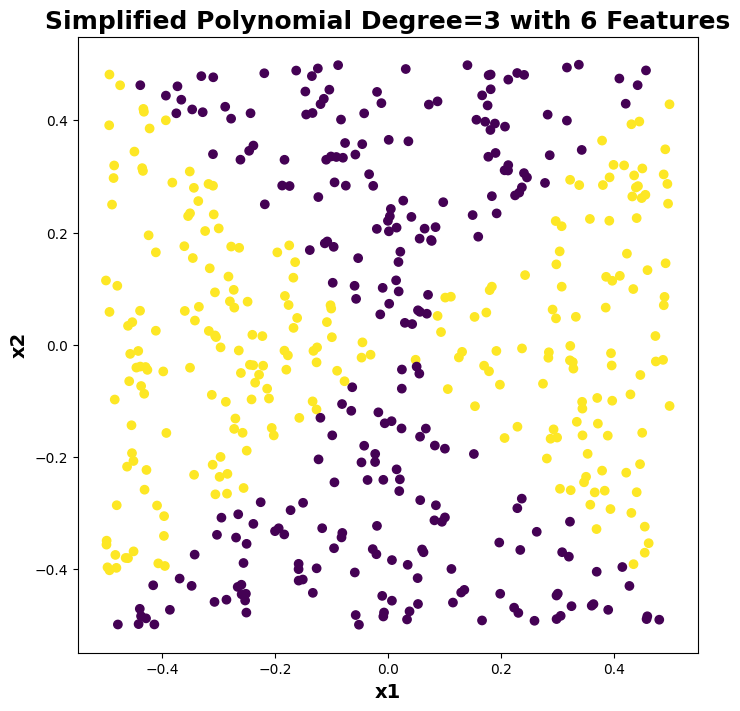

In [462]:
# Plot lr3_simplifiec
ax = subplots(figsize=(8,8))[1]
ax.scatter(X[:, 0], X[:, 1], c=y_hat_lr3_simplified)

# Customize
plt.title('Simplified Polynomial Degree=3 with 6 Features', fontsize=18, fontweight='bold')
plt.xlabel('x1', fontsize=14, fontweight='bold')
plt.ylabel('x2', fontsize=14, fontweight='bold');

In [463]:
# Create accuracy summary dataframe
accuracy_summary = pd.DataFrame()

# Compute accuracy
lr2_acc = accuracy_score(y, y_hat_lr2)
lr2_simplified_acc = accuracy_score(y, y_hat_lr2_simplified)
lr3_acc = accuracy_score(y, y_hat_lr3)
lr3_simplified_acc = accuracy_score(y, y_hat_lr3_simplified)

# Update dataframe
accuracy_summary['Model'] = [
    'lr2',
    'lr2_simplified',
    'lr3',
    'lr3_simplified'
]
accuracy_summary['Accuracy'] = [
    lr2_acc,
    lr2_simplified_acc,
    lr3_acc,
    lr3_simplified_acc
]

# Show dataframe
accuracy_summary.style.hide(axis='index')

Model,Accuracy
lr2,0.958000
lr2_simplified,0.984000
lr3,0.956000
lr3_simplified,0.984000


As expected, since we have generated the data, logistic regression models trained on simplified polynomial datasets (which exclude interaction terms and the intercept) achieve higher accuracy than those trained on datasets with standard polynomial expansions.

#### 5g)

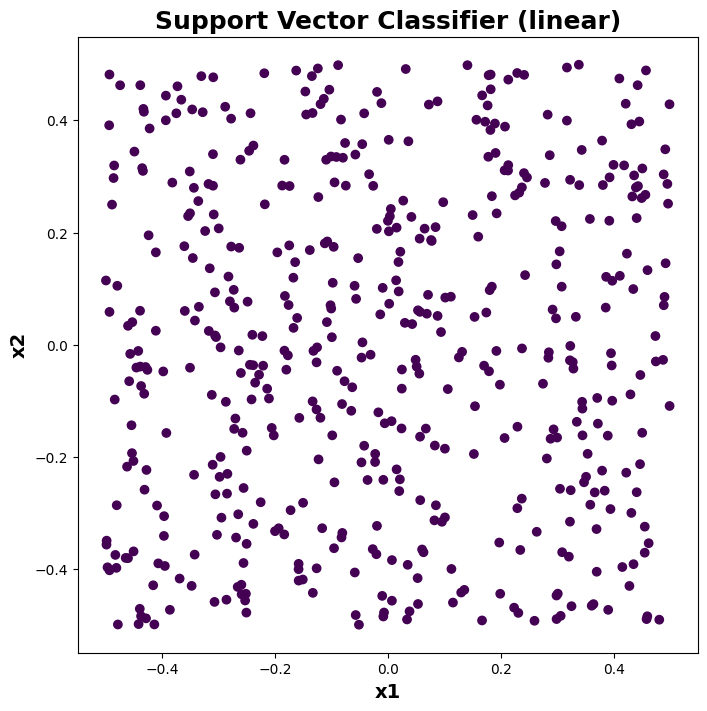

In [464]:
# Create a Support Vector Classifier
svc = SVC(kernel='linear', random_state=0).fit(X, y)

# Predict on training dataset
y_hat_svc = svc.predict(X)

# Plot
ax = subplots(figsize=(8,8))[1]
ax.scatter(X[:, 0], X[:, 1], c=y_hat_svc)

# Customize
plt.xlabel('x1', fontsize=14, fontweight='bold')
plt.ylabel('x2', fontsize=14, fontweight='bold');
plt.title('Support Vector Classifier (linear)', fontsize=18, fontweight='bold');

In [465]:
# Get the accuracy
accuracy_score(y, y_hat_svc)

0.506

In [466]:
# Confirm only one prediction class type
set(y_hat_svc)

{True}

#### 5h)

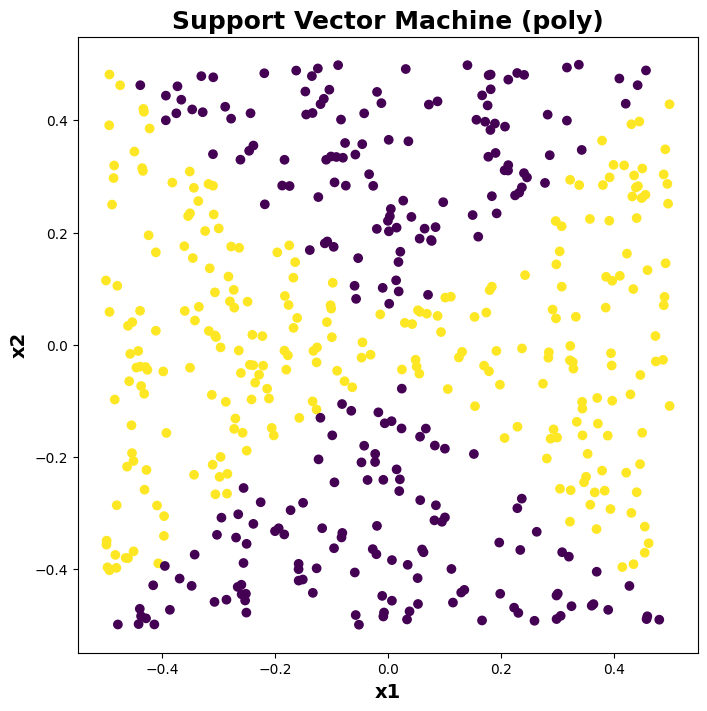

In [467]:
# Create a Support Vector Machine
svm = SVC(kernel='poly', degree=2).fit(X, y)

# Predict on training dataset
y_hat_svm = svm.predict(X)

# Plot
ax = subplots(figsize=(8,8))[1]
ax.scatter(X[:, 0], X[:, 1], c=y_hat_svm)

# Customize
plt.title('Support Vector Machine (poly)', fontsize=18, fontweight='bold')
plt.xlabel('x1', fontsize=14, fontweight='bold')
plt.ylabel('x2', fontsize=14, fontweight='bold');

In [468]:
# Compute accuracy
accuracy_score(y, y_hat_svm)

0.98

#### 5i)

After experimenting with different models and approaches, the simplicity and effectiveness of logistic regression become evident. Even when testing various polynomial degrees on the true generated data, logistic regression consistently delivers strong accuracy and reliable performance.

In contrast, the Support Vector Classifier or Machine do not achieve similar success, though it is worth noting that we did not tune its range of hyperparameters. The logistic regression even outperformed the SVM with a polynomial kernel of degree 2, despite this setting closely aligning with the original data generation process.

---

### Question 6

#### 6a)

In [469]:
# Create a generator
rng = np.random.default_rng(seed=0)

# Generate data
X = rng.normal(size=(200,2))
y = np.array([0]*100 + [1]*100)

# Create space between features
X[:100] += 1.75

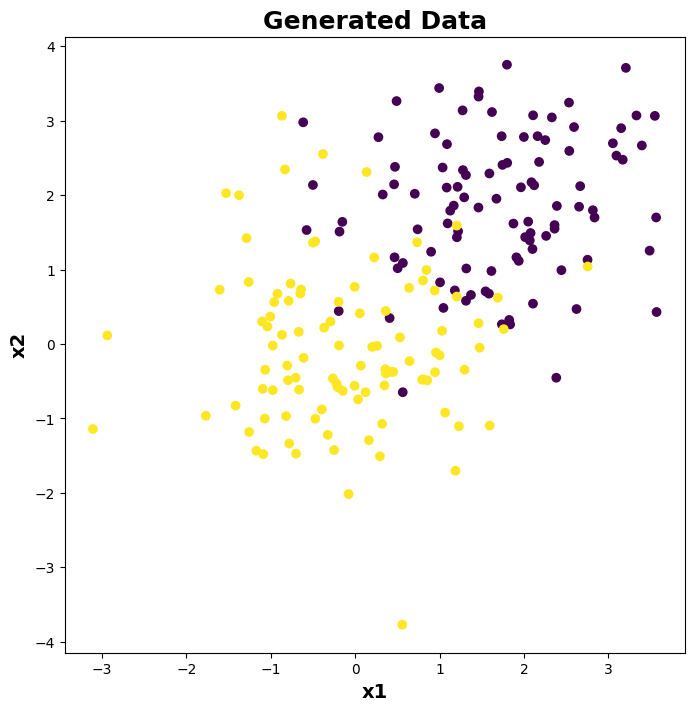

In [470]:
# Plot
ax = subplots(figsize=(8,8))[1]
ax.scatter(X[:, 0], X[:, 1], c=y)

# Customize
plt.title('Generated Data', fontsize=18, fontweight='bold')
plt.xlabel('x1', fontsize=14, fontweight='bold')
plt.ylabel('x2', fontsize=14, fontweight='bold');

#### 6b)

In [471]:
# Create the classifier
svc = SVC()

# Create the cross-validation
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# Range of 'C' values to test
param_grid = {'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}

# Set up a grid search
grid = skm.GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    refit=True,
    cv=kfold,
    scoring='accuracy'
)

# Fit
grid.fit(X, y)

# Show optimal params
grid.best_params_

{'C': 1}

In [472]:
# Save best model
model = grid.best_estimator_

# Show all accuracies
grid.cv_results_[('mean_test_score')]

array([0.61 , 0.61 , 0.875, 0.9  , 0.895, 0.89 , 0.87 ])

Above, we can see all accuracy scores computed during cross-validation. While it would be simpler to extend/project the metrics to the entire training dataset, we will take a more rigorous approach by retraining the model across all possible 'C' values.

The results suggest the potential of further optimization by trying more/better values for 'C', particurlarly between 1 and 5.

In [473]:
# Initialize a dataframe to hold accuracy results
results_train = pd.DataFrame(columns=['C', 'Accuracy'])

# Loop through C values
for C in [0.001, 0.01, 0.1, 1, 5, 10, 100]:
    # Create the model
    svc = SVC(C=C).fit(X, y)
    # Predict
    y_hat = svc.predict(X)
    # Compute accuracy
    acc = accuracy_score(y, y_hat)
    # Update dataframe
    results_train.loc[len(results_train)] = C, acc

# Add training erros to the dataframe
results_train['Errors Train'] = results_train['Accuracy'].apply(
    lambda x: (1 - x)*200
)

# Show dataframe
results_train.style.hide(axis='index')

C,Accuracy,Errors Train
0.001000,0.895000,21.000000
0.010000,0.895000,21.000000
0.100000,0.890000,22.000000
1.000000,0.895000,21.000000
5.000000,0.905000,19.000000
10.000000,0.905000,19.000000
100.000000,0.900000,20.000000


The accuracy on the training data, which is inversely related to the error rate, differs slightly from the cross-validation results. On the training set, values of 5 and 10 yield the highest accuracies, whereas cross-validation identifies 1 as the best-performing value.

#### 6c)

In [474]:
# Split the data into train/test datasets
X_train, X_test, y_train, y_test = skm.train_test_split(
    X, y, random_state=0, shuffle=True
)

In [475]:
# Create a dataframe to hold results
results_test = pd.DataFrame(columns=['C', 'Accuracy'])

# Loop through a range of C values
for C in [0.001, 0.01, 0.1, 1, 5, 10, 100]:
    # Create the model
    svc = SVC(C=C).fit(X_train, y_train)
    # Predict on test dataset
    y_hat = svc.predict(X_test)
    # Compute accuracy
    acc = accuracy_score(y_test, y_hat)
    # Update dataframe
    results_test.loc[len(results_test)] = C, acc

# Compute errors
results_test['Errors Test'] = results_test['Accuracy'].apply(
    lambda x: (1 - x)*200
)

# Show results
results_test.style.hide(axis='index')

C,Accuracy,Errors Test
0.001000,0.460000,108.000000
0.010000,0.460000,108.000000
0.100000,0.880000,24.000000
1.000000,0.880000,24.000000
5.000000,0.860000,28.000000
10.000000,0.860000,28.000000
100.000000,0.860000,28.000000


The test dataset results closely align with the cross-validation findings on the training dataset. The best accuracy is achieved with C=1, minimizing misclassification. However, unlike in cross-validation, C=0.1 now performs equally well, showing a tied accuracy with C=1.

#### 6d)

When analyzing parts 6a) to 6c), we are once again reminded of the importance of not relying solely on the results obtained from the training dataset. While a model may perform well on the training data, its true effectiveness is better assessed through cross-validation and evaluation on the test dataset.

We also observe that the results from the test dataset are more closely aligned with those obtained through cross-validation that with those from the training dataset.

Furthermore, the exercise highlights the significance of fine-tuning hyperparameters using cross-validation. Small values of 'C' suffer great variance when comparing the results on training dataset to test dataset, this is likely due to overfitting.

---

### Question 7

#### 7a)

In [476]:
# Load dataset
auto = pd.read_csv('data/Auto.csv')

# Get quick data info
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.0+ KB


In [477]:
# Create a function
def find_string(value):
    try:
        int(value)
        return False
    except:
        return True

# Filter horsepower
string_filter = auto['horsepower'].apply(find_string)
auto_strings = auto[string_filter]

# Show observations
auto_strings

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
32,25.0,4,98.0,?,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,?,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,?,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,?,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,?,2320,15.8,81,2,renault 18i


In [478]:
# Filter dataset
auto_filtered = auto[auto['horsepower'] != '?'].copy()

# Adapt 'horsepower' to integer
auto_filtered['horsepower'] = auto_filtered['horsepower'].astype(int)

In [479]:
# Get number of unique 'name'
name_unique = len(set(auto_filtered['name']))

# Print insights
print(f"""
dataset size  = {len(auto_filtered)}
unique 'name' = {name_unique}
""")


dataset size  = 392
unique 'name' = 301



We see a high number of unique 'name' in comparison to the number of observations in the dataset. This feature is unlikely to add value to model performance in its original/unmodified state. One potential idea is to only use the brand's name (e.g. ford, renault, etc).

In [480]:
# Describe response variable/feature
auto_filtered['mpg'].describe()

count    392.000000
mean      23.445918
std        7.805007
min        9.000000
25%       17.000000
50%       22.750000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

In [481]:
# Get median value for 'mpg'
median = auto_filtered['mpg'].median()

# Create a binary response variable for high gas mileage
y = auto_filtered['mpg'].apply(lambda x: 1 if x > median else 0)

#### 7b)

In [482]:
# Create feature dataset
X = auto_filtered.iloc[:, 1:-1].copy()

# Create a scaled alternative
X_scaled = scale(X)

# Split datasets into train/test
X_train, X_test, y_train, y_test = skm.train_test_split(
    X, y, random_state=0, shuffle=True
)
X_scaled_train, X_scaled_test, _, _ = skm.train_test_split(
    X_scaled, y, random_state=0, shuffle=True
)

In [483]:
# Range of 'C' values to test
C_list = [0.001, 0.01, 0.1, 1, 5, 10, 100]

# Create a param_grid
param_grid = {'C': C_list}

# Set up a model
svc = SVC()

# Create a cross-validation method
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# Create a grid
grid = skm.GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    refit=True,
    cv=kfold
)

# Create a grid for the scaled data
grid_scaled = skm.GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    refit=True,
    cv=kfold
)

# Fit
grid.fit(X_train, y_train)
grid_scaled.fit(X_scaled_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]},
             scoring='accuracy')

In [484]:
# Create accuracy dataframe for regular data
results_regular = pd.DataFrame({
    'C': C_list,
    'Accuracy CV': grid.cv_results_[('mean_test_score')]
})

# Show results
results_regular.style.hide(axis='index')

C,Accuracy CV
0.001000,0.458391
0.010000,0.458391
0.100000,0.897931
1.000000,0.904713
5.000000,0.904713
10.000000,0.897816
100.000000,0.907701


In [485]:
# Create accuracy dataframe for scaled data
results_scaled = pd.DataFrame({
    'C': C_list,
    'Accuracy CV': grid_scaled.cv_results_[('mean_test_score')]
})

# Show cv accuracy on scaled data
results_scaled.style.hide(axis='index')

C,Accuracy CV
0.001000,0.468391
0.010000,0.591034
0.100000,0.931609
1.000000,0.928276
5.000000,0.948851
10.000000,0.952299
100.000000,0.948851


Due to the varying scale of features in the dataset, ranging from values in single digits to other in the hundres or thousands (e.g., 'weight'), scaling the dta significantly enhances model performance.

The best result is achieved with a Support Vector Classifier using C=10, yielding a cross-validation accuracy of roughly 95.23%. This indicates that the model correctly predicts whether a car's fuel efficiency falls below or above the median value of 22.75 mpg in 95.23% of cases.

#### 7c)

In [486]:
# Lists with values to test in a grid search
c_list = [0.001, 0.01, 0.1, 1, 5, 10, 100]
kernel_list = ['poly', 'rbf']
degree_list = [2, 3]
gamma_list = ['scale', 'auto', 3, 2, 1, 0.1, 0.01, 0.001]

# Set up a param_grid
param_grid = {
    'C': c_list,
    'kernel': kernel_list,
    'degree': degree_list,
    'gamma': gamma_list
}

# Create cross-validation method
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# Create a model/predictor
svm = SVC()

# Set up grid
grid = skm.GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    refit=True,
    cv=kfold
)

# Fit
grid.fit(X_scaled_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 5, 10, 100],
                         'degree': [2, 3],
                         'gamma': ['scale', 'auto', 3, 2, 1, 0.1, 0.01, 0.001],
                         'kernel': ['poly', 'rbf']},
             scoring='accuracy')

In [487]:
# How many tests were made
tests_len = len(grid.cv_results_[('mean_test_score')])

# Best Accuracy
best_acc = grid.cv_results_[('mean_test_score')].max()

# Print information
print(f"""
Grid serch tests: {tests_len}

Best accuracy:    {round(best_acc, 4)}
""")


Grid serch tests: 224

Best accuracy:    0.9589



In [488]:
# Save results in a dataframe
results = pd.DataFrame(grid.cv_results_[('params')])

# Add accuracy
results['accuracy_cv'] = grid.cv_results_[('mean_test_score')]

# Sort by accuracy
results.sort_values(by='accuracy_cv', ascending=False, inplace=True)

# Show top 15 results
results.iloc[:15]

,C,degree,gamma,kernel,accuracy_cv
121,1.00,3,1,rbf,0.958851
105,1.00,2,1,rbf,0.958851
169,10.00,2,1,rbf,0.955632
185,10.00,3,1,rbf,0.955632
137,5.00,2,1,rbf,0.955517
153,5.00,3,1,rbf,0.955517
161,10.00,2,scale,rbf,0.952299
177,10.00,3,scale,rbf,0.952299
179,10.00,3,auto,rbf,0.952299
163,10.00,2,auto,rbf,0.952299


When analyzing the best models by cross-validation accuracy, it is interesting to observe that multiple parameter configurations yield similar results. However, there is a consistent trend: models using the radial basis function ('rbf') kernel consistently achieve the highest accuracies, outperforming those with the polynomial ('poly') kernel.

The best-performing polynomial kernel model requires a high degree of flexibility from its hyperparameters: C=0.01, which leads to narrow margins for the separating hyperplane; degree=3, the highest polynomial degree tested; and gamma=3, the larget value in our search, which incrases model flexibility by emphasizing the influence of closer training observations while reducing the impact of those further away.

While polynomial kernels can still be effective for this task, they demand more tuning and flexibility to compete with the performance of the 'rbf' kernel.

#### 7d)

In [489]:
# Check shape of the feature matrix
X_scaled_train.shape

(294, 7)

This dataset consists of 7 features. While this may be considered relatively small by modern standards, it is still large enough to limit our ability to visualize the data effectively using plots.

One approach to improving our analysis is to identify the most important features for predicting 'y' and visualize them in pairs. This can provide some insights into their relationships and predictive power. However, even with this approach, we are still capturing a partial view of the full 7 dimensional dataset.

In [490]:
# Create a function to perform forward selection
def forward_selection(X, y):

    # Make sure the data is np.array
    X_ = np.asarray(X)
    y_ = np.asarray(y)

    # Get the column index of features
    features_current = list(range(X.shape[1]))

    # Selected features so far
    features_selection = []

    # Accuracies so far
    features_acc = []

    # Loop while there are features
    while features_current:

        # Initialize selection variables
        feature_best = None
        acc_best = -float('inf')

        # Loop through features
        for i in features_current:

            # Set up cross-validation method
            kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

            # Initialize accuracy CV list
            acc_cv_list = []

            # Gather all features
            features_model = features_selection + [i]

            # Filter data
            X_filtered = X_[:, features_model]

            # Loop through kfolds
            for train_idx, eval_idx in kfold.split(X_):

                # Get the data for each fold
                X_train_, X_eval_ = X_filtered[train_idx], X_filtered[eval_idx]
                y_train_, y_eval_ = y_[train_idx], y_[eval_idx]
                
                # Create and fit the 'optimal' model
                model = SVC(C=1, degree=3, gamma=1, kernel='rbf').fit(X_train_, y_train_)

                # Predict on eval & compute accuracy
                y_hat_ = model.predict(X_eval_)
                acc = accuracy_score(y_eval_, y_hat_)
                acc_cv_list.append(acc)

            # Compute CV accuracy
            acc_cv = np.mean(acc_cv_list)

            # Check if it is best accuracy
            if acc_cv > acc_best:
                acc_best = acc_cv
                feature_best = i

        # Update features lists
        features_acc.append(acc_best)
        features_selection.append(feature_best)
        features_current.remove(feature_best)

    return features_selection, features_acc

In [491]:
# Apply function
features_selection, features_acc = forward_selection(X_scaled_train, y_train)

# Get features names
features_names = X.columns

# Create a dataframe with the results
results_forward_selection = pd.DataFrame({
    'Features': features_names[features_selection],
    'Accuracy CV': features_acc
})

# Show results
results_forward_selection

,Features,Accuracy CV
0,displacement,0.918161
1,year,0.921609
2,weight,0.948851
3,cylinders,0.952184
4,horsepower,0.955517
5,origin,0.952069
6,acceleration,0.958851


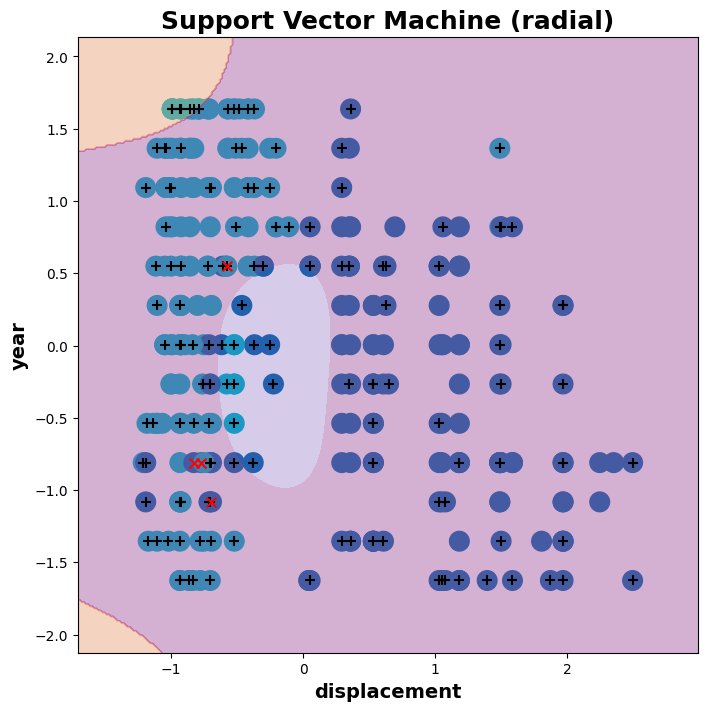

In [493]:
# Create ax
ax = subplots(figsize=(8,8))[1]

# Features rankings
r0, r1 = features_selection[0], features_selection[1]

# Plot
plot_svm(
    X_scaled_train,
    np.asarray(y_train),
    grid.best_estimator_,
    (r0, r1),
    ax=ax
)

# Customize
ax.set_title('Support Vector Machine (radial)', fontsize=18, fontweight='bold')
ax.set_xlabel(features_names[r0], fontsize=14, fontweight='bold')
ax.set_ylabel(features_names[r1], fontsize=14, fontweight='bold');

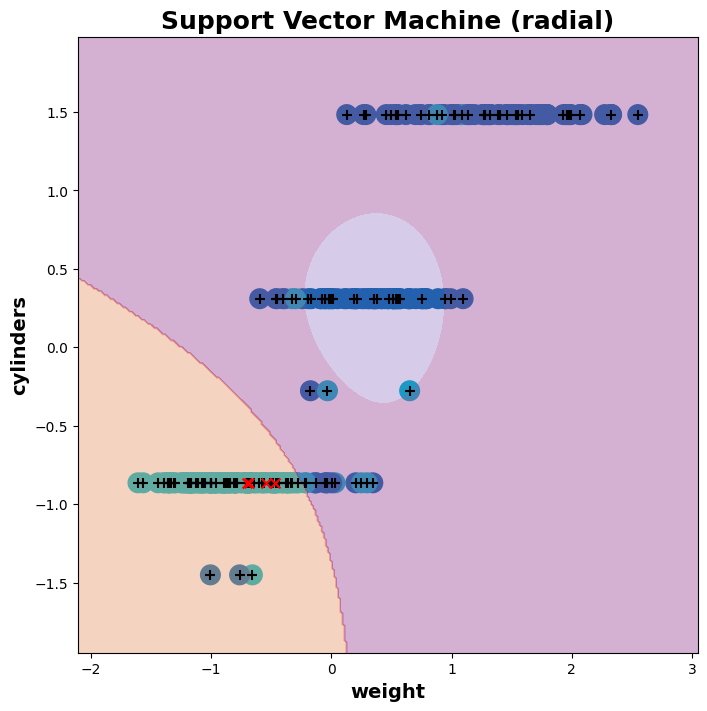

In [494]:
# Create ax
ax = subplots(figsize=(8,8))[1]

# Features rankings
r2, r3 = features_selection[2], features_selection[3]
# Plot
plot_svm(
    X_scaled_train,
    np.asarray(y_train),
    grid.best_estimator_,
    (r2, r3),
    ax=ax
)

# Add axis' titles
ax.set_title('Support Vector Machine (radial)', fontsize=18, fontweight='bold')
ax.set_xlabel(features_names[r2], fontsize=14, fontweight='bold')
ax.set_ylabel(features_names[r3], fontsize=14, fontweight='bold');

As expected, visualizing a high-dimensional hyperplane in a 2D plot is challenging. The dection boundaries between classes are not immediately apparent when examining feature pairs, making it less intuitive to interpret the model's separations.

However, an interesting observation is that the 'displacement' feature alone appears to be highly predictive, achieving approximately 91.81% accuracy in cross-validation. This suggests that certain individual features carry strong predicive power, even in the presence of a more complex, high-dimensional feature space.

---

### Question 8

#### 8a)

In [365]:
# Load dataset
oj = pd.read_csv('data/OJ.csv')

# Quick info
oj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Purchase        1070 non-null   object 
 1   WeekofPurchase  1070 non-null   int64  
 2   StoreID         1070 non-null   int64  
 3   PriceCH         1070 non-null   float64
 4   PriceMM         1070 non-null   float64
 5   DiscCH          1070 non-null   float64
 6   DiscMM          1070 non-null   float64
 7   SpecialCH       1070 non-null   int64  
 8   SpecialMM       1070 non-null   int64  
 9   LoyalCH         1070 non-null   float64
 10  SalePriceMM     1070 non-null   float64
 11  SalePriceCH     1070 non-null   float64
 12  PriceDiff       1070 non-null   float64
 13  Store7          1070 non-null   object 
 14  PctDiscMM       1070 non-null   float64
 15  PctDiscCH       1070 non-null   float64
 16  ListPriceDiff   1070 non-null   float64
 17  STORE           1070 non-null   i

In [366]:
# Check initial observations
oj.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


In [367]:
# Check possible responses
set(oj['Purchase'])

{'CH', 'MM'}

In [368]:
# Create datasets
X = pd.get_dummies(oj.iloc[:, 1:], drop_first=True, dtype='int')
X = scale(X) # scale the data
y = oj['Purchase'].copy()

# Split into train/test
X_train, X_test, y_train, y_test = skm.train_test_split(
    X, y, train_size=800, random_state=0
)

#### 8b)

In [369]:
# Create & fit a model
svc = SVC(C=0.01, kernel='linear').fit(X_train, y_train)

# Check the number of support vectors
svc.n_support_

array([215, 214], dtype=int32)

We have 429 support points: 215 for 'CH' and 214 for 'MM'.

#### 8c)

In [370]:
# Predict on train & test datasets
y_hat_train = svc.predict(X_train)
y_hat_test = svc.predict(X_test)

# Compute accuracy
acc_train = accuracy_score(y_train, y_hat_train)
acc_test = accuracy_score(y_test, y_hat_test)

# Print information
print(f"""
acc_train: {round(acc_train, 4)}
acc_test:  {round(acc_test, 4)}

error_train: {round(1 - acc_train, 4)}
error_test:  {round(1 - acc_test, 4)}
""")


acc_train: 0.8337
acc_test:  0.8074

error_train: 0.1663
error_test:  0.1926



#### 8d)

In [371]:
# Create a model
svc = SVC(kernel='linear')

# Set up a k-fold cross-validation method
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# List of C values to test
c_list = [0.01, 0.05, 0.1, 0.5, 1, 2, 3, 4, 5, 10]

# Create a param_grid
param_grid = {'C': c_list}

# Set up a grid search
grid = skm.GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    refit=True,
    cv=kfold
)

# Fit
grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=SVC(kernel='linear'), n_jobs=-1,
             param_grid={'C': [0.01, 0.05, 0.1, 0.5, 1, 2, 3, 4, 5, 10]},
             scoring='accuracy')

In [372]:
# Show best 'C' param
grid.best_params_

{'C': 0.1}

#### 8e)

In [374]:
# Save 'optimal' model
model = grid.best_estimator_

# Predict on train & test datasets
y_hat_train = model.predict(X_train)
y_hat_test = model.predict(X_test)

# Compute accuracy
acc_train = accuracy_score(y_train, y_hat_train)
acc_test = accuracy_score(y_test, y_hat_test)

# Store result on test dataset for latter use
acc_test_linear = acc_test

# Print info
print(f"""
SVC - Linear Kernel
-------------------

acc_train: {round(acc_train, 4)}
acc_test:  {round(acc_test, 4)}

error_train: {round(1 - acc_train, 4)}
error_test:  {round(1 - acc_test, 4)}
""")


SVC - Linear Kernel
-------------------

acc_train: 0.8425
acc_test:  0.8259

error_train: 0.1575
error_test:  0.1741



#### 8f)

In [375]:
# Create a model
svm = SVC(C=0.01, kernel='rbf').fit(X_train, y_train)

# Check support points
svm.n_support_

array([304, 300], dtype=int32)

In [376]:
# Predict
y_hat_train = svm.predict(X_train)
y_hat_test = svm.predict(X_test)

# Compute accuracy
acc_train = round(accuracy_score(y_train, y_hat_train), 4)
acc_test = round(accuracy_score(y_test, y_hat_test), 4)

# Compute error
error_train = round(1 - acc_train, 4)
error_test = round(1 - acc_test, 4)

# Print info
print(f"""
acc_train:   {acc_train}
acc_test:    {acc_test}

error_train: {error_train}
error_test:  {error}
""")


acc_train:   0.625
acc_test:    0.5667

error_train: 0.375
error_test:  0.3897



In [377]:
# Create a model
svc = SVC(kernel='rbf')

# Set up a k-fold cross-validation method
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# List of C values to test
c_list = [0.01, 0.05, 0.1, 0.5, 1, 2, 3, 4, 5, 10]

# Create a param_grid
param_grid = {'C': c_list}

# Set up a grid search
grid = skm.GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    refit=True,
    cv=kfold
)

# Fit
grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.05, 0.1, 0.5, 1, 2, 3, 4, 5, 10]},
             scoring='accuracy')

In [378]:
# Save 'optimal' model
model = grid.best_estimator_

# Predict on train & test datasets
y_hat_train = model.predict(X_train)
y_hat_test = model.predict(X_test)

# Compute accuracy
acc_train = round(accuracy_score(y_train, y_hat_train), 4)
acc_test = round(accuracy_score(y_test, y_hat_test), 4)

# Compute error
error_train = round(1 - acc_train, 4)
error_test = round(1 - acc_test, 4)

# Store result on test dataset for latter use
acc_test_radial = acc_test

# Print information
print(f"""
SVM - Radial Kernel
-------------------

acc_train:    {acc_train}
acc_test:     {acc_test}

error_train:  {error_train}
error_test:   {error_test}
""")


SVM - Radial Kernel
-------------------

acc_train:    0.8575
acc_test:     0.8185

error_train:  0.1425
error_test:   0.1815



#### 8g)

In [379]:
# Create & fit a SVM with 'poly' kernel
svm = SVC(C=0.01, kernel='poly', degree=2).fit(X_train, y_train)

# Check how many support points
svm.n_support_

array([307, 300], dtype=int32)

In [380]:
# Predict on train & test datasets
y_hat_train = svm.predict(X_train)
y_hat_test = svm.predict(X_test)

# Compute accuracy
acc_train = round(accuracy_score(y_train, y_hat_train), 4)
acc_test = round(accuracy_score(y_test, y_hat_test), 4)

# Compute error
error_train = round(1 - acc_train, 4)
error_test = round(1 - acc_test, 4)

# Print information
print(f"""
acc_train:   {acc_train}
acc_test:    {acc_test}

error_train: {error_train}
error_test:  {error_test}
""")


acc_train:   0.625
acc_test:    0.5667

error_train: 0.375
error_test:  0.4333



In [381]:
# Create a model
svm = SVC(kernel='poly', degree=2)

# Set up a k-fold cross-validation method
kfold = skm.KFold(n_splits=10, shuffle=True, random_state=0)

# List of C values to test
c_list = [0.01, 0.05, 0.1, 0.5, 1, 2, 3, 4, 5, 10]

# Create a param_grid
param_grid = {'C': c_list}

# Set up a grid search
grid = skm.GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    refit=True,
    cv=kfold
)

# Fit
grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.05, 0.1, 0.5, 1, 2, 3, 4, 5, 10]},
             scoring='accuracy')

In [382]:
# Get the 'optimal' model
model = grid.best_estimator_

# Predict on train & test datasets
y_hat_train = model.predict(X_train)
y_hat_test = model.predict(X_test)

# Compute accuracy
acc_train = round(accuracy_score(y_train, y_hat_train), 4)
acc_test = round(accuracy_score(y_test, y_hat_test), 4)

# Compute error
error_train = round(1 - acc_train, 4)
error_test = round(1 - acc_test, 4)

# Store result on test dataset for latter use
acc_test_poly = acc_test

# Print information
print(f"""
SVM - Polynomial Kernel
-----------------------

acc_train:   {acc_train}
acc_test:    {acc_test}

error_train: {error_train}
error_test:  {error_test}
""")


SVM - Polynomial Kernel
-----------------------

acc_train:   0.8575
acc_test:    0.8185

error_train: 0.1425
error_test:  0.1815



#### 8h)

In [385]:
# Create a final results dataframe
results = pd.DataFrame({
    'Model': ['SVC - Linear', 'SVM - Radial', 'SVM - Poly'],
    'Acc Test': [acc_test_linear, acc_test_radial, acc_test_poly]
})

# Show results
results.style.hide(axis='index')

Model,Acc Test
SVC - Linear,0.825926
SVM - Radial,0.818500
SVM - Poly,0.818500


All models exhibit similar performance, but the Support Vector Classifier (SVC) with a linear kernel achieves slightly higher accuracy on the test dataset.

Given the high-dimensional nature of the data, we may not have enough observations to fully leverage more complex models like Support Vector Machine with radial or polynomial kernels. Both of these models rely heavily on support vectors, using over 600 out of the 800 training obseravtions to construct the decision boundary. This means that approximately 75% (3/4) of the training data is being utilized as support vectors.

In contrast, the SVC with a linear kernel uses 429 support vectors out of the 800 training observations. While this is still a significant proportion, it is lower than the other models. This likely allows the model to generalize better, leading to higher accuracy. Despite being a simpler model that cannot capture complex non-linear patterns, it still outperforms the more flexible alternatives.

With the given dataset, the SVC with a linear kernel provides the best results. For the more complex models, additional data would likely be necessary to determine whether they can surpass the performance of the linear approach.